<a href="https://colab.research.google.com/github/loop-hack/classifiaction_model/blob/main/ResNet_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
aimport keras
from keras.layers import Dense, Conv2D, BatchNormalization, Activation
from keras.layers import AveragePooling2D, Input, Flatten
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2
from keras import backend as K
from keras.models import Model
# from keras.datasets import cifar10 # Import cifar10 directly
import numpy as np
import os

In [ ]:
! pip install kaggle

In [ ]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download drwhile/indian-bovine-breeds

Dataset URL: https://www.kaggle.com/datasets/drwhile/indian-bovine-breeds
License(s): unknown
 99% 766M/776M [00:02<00:00, 241MB/s]
100% 776M/776M [00:03<00:00, 209MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("indian-bovine-breeds.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/Indian_bovine_breeds",
    image_size=(224, 224),
    batch_size=32
)
class_names = train_ds.class_names # Get class names here

Found 2105 files belonging to 10 classes.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Banni', 'Gir', 'Jaffrabadi', 'Jersey', 'Kankrej', 'Murrah', 'Nagpuri', 'Sahiwal', 'Tharparkar', 'Toda']


In [ ]:
batch_size = 16
epochs = 15
data_augmentation = True
num_classes = 10
subtract_pixel_mean = False # Set to False as scaling is handled by image_dataset_from_directory
n = 3
version = 1

if version == 1:
    depth = n * 6 + 2
elif version == 2:
    depth = n * 6 + 2

model_type = 'ResNet % dv % d' % (depth, version)

# Load data using image_dataset_from_directory in cell OPtPUQOa6x1r

# Split train_ds into training and validation sets
train_size = tf.data.experimental.cardinality(train_ds).numpy()
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

val_size = int(train_size * 0.2) # Use 20% of data for validation
val_ds = train_ds.take(val_size)
train_ds = train_ds.skip(val_size)

input_shape = (224, 224, 3) # Image size from image_dataset_from_directory

# Data normalization and mean subtraction are handled by image_dataset_from_directory

print('Number of training samples:', tf.data.experimental.cardinality(train_ds).numpy() * batch_size)
print('Number of validation samples:', tf.data.experimental.cardinality(val_ds).numpy() * batch_size)
print('Input shape:', input_shape)


# The labels are already integers with image_dataset_from_directory, no need for one-hot encoding
# y_train = keras.utils.to_categorical(y_train, num_classes)
# y_test = keras.utils.to_categorical(y_test, num_classes)

Number of training samples: 848
Number of validation samples: 208
Input shape: (224, 224, 3)


In [ ]:
def lr_schedule(epoch):
  lr = 1e-3
  if epoch > 5:
    lr *= 0.5e-3
  print('Learning rate: ', lr)
  return lr

In [ ]:
def resnet_layer(inputs,
                 num_filters = 16,
                 kernel_size = 3,
                 strides = 1,
                 activation = 'relu',
                 batch_normalization = True,
                 conv_first = True):
  conv = Conv2D(num_filters,
                kernel_size = kernel_size,
                strides = strides,
                padding = 'same',
                kernel_initializer = 'he_normal',
                kernel_regularizer = l2(1e-4))

  x = inputs
  if conv_first:
    x = conv(x)
    if batch_normalization:
      x = BatchNormalization()(x)
    if activation is not None:
      x = Activation(activation)(x)
  else:
    if batch_normalization:
      x = BatchNormalization()(x)
    if activation is not None:
      x = Activation(activation)(activation)
    x = conv(x)

  return x

In [ ]:
###################################################################
###################################################################


#Corrected Version

In [ ]:
# Kaggle API call
! mkdir -p ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download drwhile/indian-bovine-breeds #downloading the dataset

In [ ]:
import zipfile
import os

# dataset download
!kaggle datasets download drwhile/indian-bovine-breeds -f indian-bovine-breeds.zip

# extracting the dataset
with zipfile.ZipFile("indian-bovine-breeds.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [ ]:
import tensorflow as tf

# Load data using image_dataset_from_directory
data_dir = "/content/dataset/Indian_bovine_breeds"
if os.path.exists(data_dir):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        image_size=(224, 224),
        batch_size=32, # Initial batch size for loading
        shuffle=True # Shuffle initially
    )
    class_names = train_ds.class_names # Get class names here
    print("Class names loaded successfully:", class_names)

    batch_size = 16 # Batch size for training
    epochs = 25 # Increased epochs for better training
    data_augmentation = True
    num_classes = len(class_names) # Use the actual number of classes
    subtract_pixel_mean = False
    n = 3
    version = 1

    if version == 1:
        depth = n * 6 + 2
    elif version == 2:
        depth = n * 6 + 2

    model_type = 'ResNet % dv % d' % (depth, version)

    # Split train_ds into training and validation sets
    train_size = tf.data.experimental.cardinality(train_ds).numpy()
    val_size = int(train_size * 0.2) # Use 20% of data for validation

    val_ds = train_ds.take(val_size)
    train_ds = train_ds.skip(val_size)

    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE) # Cache and prefetch validation set as well

    input_shape = (224, 224, 3) # Image size from image_dataset_from_directory

    # Data normalization and mean subtraction are handled by image_dataset_from_directory

    print('Number of training samples:', tf.data.experimental.cardinality(train_ds).numpy() * batch_size)
    print('Number of validation samples:', tf.data.experimental.cardinality(val_ds).numpy() * batch_size)
    print('Input shape:', input_shape)
else:
    print(f"Dataset directory not found at {data_dir}. Please ensure the dataset is downloaded and extracted correctly.")

Found 2105 files belonging to 10 classes.
Class names loaded successfully: ['Banni', 'Gir', 'Jaffrabadi', 'Jersey', 'Kankrej', 'Murrah', 'Nagpuri', 'Sahiwal', 'Tharparkar', 'Toda']
Number of training samples: 848
Number of validation samples: 208
Input shape: (224, 224, 3)


In [ ]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast, RandomTranslation, RandomCrop

# Define and apply data augmentation
data_augmentation_layers = tf.keras.Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.3), # Increased rotation range
    RandomZoom(height_factor=(-0.3, -0.1), width_factor=(-0.3, -0.1)), # Increased zoom range
    RandomContrast(factor=0.3), # Increased contrast range
    RandomTranslation(height_factor=0.2, width_factor=0.2), # Increased translation range
    RandomCrop(height=224, width=224) # Added random crop, changed size to match input_shape
])

In [ ]:
def augment_image(image, label):
    """Applies data augmentation layers to an image."""
    augmented_image = data_augmentation_layers(image, training=True)
    return augmented_image, label

train_ds = train_ds.map(augment_image)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
from keras.layers import Dense, Conv2D, BatchNormalization, Activation
from keras.layers import AveragePooling2D, Input, Flatten
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from keras.callbacks import ReduceLROnPlateau
from keras.regularizers import l2
from keras import backend as K
from keras.models import Model


def lr_schedule(epoch):
  lr = 1e-3
  if epoch > 5:
    lr *= 0.5e-3
  print('Learning rate: ', lr)
  return lr

def resnet_layer(inputs,
                 num_filters = 16,
                 kernel_size = 3,
                 strides = 1,
                 activation = 'relu',
                 batch_normalization = True,
                 conv_first = True):
  conv = Conv2D(num_filters,
                kernel_size = kernel_size,
                strides = strides,
                padding = 'same',
                kernel_initializer = 'he_normal',
                kernel_regularizer = l2(1e-4))

  x = inputs
  if conv_first:
    x = conv(x)
    if batch_normalization:
      x = BatchNormalization()(x)
    if activation is not None:
      x = Activation(activation)(x)
  else:
    if batch_normalization:
      x = BatchNormalization()(x)
    if activation is not None:
      x = Activation(activation)(activation)
    x = conv(x)

  return x

def resnet_v1(input_shape, depth, num_classes = 10):
  if (depth - 2) % 6 != 0:
    raise ValueError('depth should be 6n + 2 (eg 20, 32, 44 in [a])')

  num_filters = 16
  num_res_blocks = int((depth - 2) / 6)

  inputs  = Input(shape=input_shape)
  x = resnet_layer(inputs = inputs)


  for stack in range(3):
    for res_block in range(num_res_blocks):
      strides = 1
      if stack > 0 and res_block == 0:
        strides = 2
      y = resnet_layer(inputs = x,
                       num_filters = num_filters,
                       strides = strides)
      y = resnet_layer(inputs = y,
                       num_filters = num_filters,
                       activation = None)
      if stack > 0 and res_block == 0:
        x = resnet_layer(inputs = x,
                         num_filters = num_filters,
                         kernel_size = 1,
                         strides = strides,
                         activation = None,
                         batch_normalization = False)
      x = keras.layers.add([x, y])
      x = Activation('relu')(x)
    num_filters *= 2

  x = AveragePooling2D(pool_size = 8)(x)
  y = Flatten()(x)
  outputs = Dense(num_classes,
                  activation = 'softmax',
                  kernel_initializer = 'he_normal')(y)

  model = Model(inputs = inputs, outputs = outputs)
  return model

def resnet_v2(input_shape, depth, num_classes = 10):
  if (depth - 2) % 9 != 0:
    raise ValueError('depth should be 9n + 2 (eg 56 or 110 in [b])')

  num_filters_in = 16
  num_res_blocks = int((depth - 2) / 9)

  inputs = Input(shape = input_shape)
  x = resnet_layer(inputs = inputs,
                   num_filters = num_filters_in,
                   conv_first = True)

  for stage in range(3):
    for res_block in range(num_res_blocks):
      activation = 'relu'
      batch_normalization = True
      strides = 1
      if stage == 0:
        num_filters_out = num_filters_in * 4
        if res_block == 0:
          activation = None
          batch_normalization = False

      else:
        num_filters_out = num_filters_in * 2
        if res_block == 0:
          strides = 2


        y = resnet_layer(inputs = x,
                         num_filters = num_filters_in,
                         kernel_size = 1,
                         strides = strides,
                         activation = activation,
                         batch_normalization = batch_normalization,
                         conv_first = False)
        y = resnet_layer(inputs = y,
                         num_filters = num_filters_in,
                         conv_first = False)
        y = resnet_layer(inputs = y,
                         num_filters = num_filters_out,
                         kernel_size = 1,
                         conv_first = False)
        if res_block == 0:
          x = resnet_layer(inputs = x,
                           num_filters = num_filters_out,
                           kernel_size = 1,
                           strides = strides,
                           activation = None,
                           batch_normalization = False)
        x = keras.layers.add([x, y])

      num_filters_in = num_filters_out

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling2D(pool_size = 8)(x)
    y = Flatten()(x)
    outputs = Dense(num_classes,
                    activation = 'softmax',
                    kernel_initializer = 'he_normal')(y)

    model = Model(inputs = inputs, outputs = outputs)
    return model

In [ ]:
# Instantiate and compile the ResNet model
if version == 2:
  model = resnet_v2(input_shape = input_shape, depth = depth, num_classes=num_classes)
else:
  model = resnet_v1(input_shape = input_shape, depth = depth, num_classes=num_classes) # Added num_classes argument

model.compile(loss='sparse_categorical_crossentropy', # Changed loss to sparse_categorical_crossentropy
              optimizer = Adam(learning_rate = lr_schedule(0)),
              metrics = ['accuracy'])

model.summary()
print(model_type)

save_dir = os.path.join(os.getcwd(), 'saved_models')
model_name = 'cifar10_%s_model.{epoch:03d}.keras' % model_type

if not os.path.isdir(save_dir):
  os.makedirs(save_dir)
filepath = os.path.join(save_dir, model_name)

checkpoint = ModelCheckpoint(filepath = filepath,
                             monitor = 'val_accuracy', # Corrected to val_accuracy
                             verbose = 1,
                             save_best_only = True)

lr_scheduler = LearningRateScheduler(lr_schedule)

lr_reducer = ReduceLROnPlateau(factor = np.sqrt(0.1),
                               cooldown = 0,
                               patience = 5,
                               min_lr = 0.5e-6)

callbacks = [checkpoint, lr_reducer, lr_scheduler]

# Calculate steps per epoch using the dataset size
train_size = tf.data.experimental.cardinality(train_ds).numpy() # Calculate total number of training samples
steps_per_epoch = train_size // batch_size
val_steps_per_epoch = tf.data.experimental.cardinality(val_ds).numpy() # Calculate steps for validation


print('Using real-time data augmentation.')
# Data augmentation is handled by image_dataset_from_directory if specified during creation
# If you want more advanced augmentation, you can use Keras preprocessing layers

model.fit(train_ds.repeat(epochs), # Repeat the dataset for the number of epochs
          steps_per_epoch = steps_per_epoch,
          epochs = epochs,
          validation_data = val_ds, # Use val_ds for validation
          validation_steps = val_steps_per_epoch, # Add validation steps
          callbacks = callbacks)

Learning rate:  0.001


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │      2,320 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ activation[0][0], │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │      2,320 │ activation_2[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 224, 224,  │      2,320 │ activation_3[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         64 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ activation_2[0][

 Total params: 305,162 (1.16 MB)

 Trainable params: 303,786 (1.16 MB)

 Non-trainable params: 1,376 (5.38 KB)

ResNet  20v  1
Using real-time data augmentation.
Learning rate:  0.001
Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.1000 - loss: 3.6737 
Epoch 1: val_accuracy improved from -inf to 0.10337, saving model to /content/saved_models/cifar10_ResNet  20v  1_model.001.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 164s 49s/step - accuracy: 0.1031 - loss: 3.8240 - val_accuracy: 0.1034 - val_loss: 248.0641 - learning_rate: 0.0010
Learning rate:  0.001
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.2274 - loss: 4.9175 
Epoch 2: val_accuracy did not improve from 0.10337
3/3 ━━━━━━━━━━━━━━━━━━━━ 115s 47s/step - accuracy: 0.2201 - loss: 4.7829 - val_accuracy: 0.1034 - val_loss: 92.0996 - learning_rate: 0.0010
Learning rate:  0.001
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.1788 - loss: 3.8696 
Epoch 3: val_accuracy did not improve from 0.10337
3/3 ━━━━━━━━━━━━━━━━━━━━ 114s 47s/step - accuracy: 0.1784 - loss: 3.7962 - val_accuracy: 0.0841 - val_loss: 63.4172 - lear

In [ ]:
# Save the trained model to the specified path
model_path = "my_model.h5"
try:
    model.save(model_path)
    print(f"Model saved successfully to {model_path}")
except Exception as e:
    print(f"Error saving model: {e}")
    model = None # Set model to None if saving fails

Model saved successfully to my_model.h5


In [ ]:
import numpy as np
from PIL import Image
import tensorflow as tf
import os


# Define the path to the saved model file
model_path = "my_model.h5" # Assuming the model was saved to this path in a previous step

# Load the trained model
try:
    loaded_model = tf.keras.models.load_model(model_path)
    print(f"Model loaded successfully from {model_path}")
except Exception as e:
    print(f"Error loading model: {e}")
    loaded_model = None # Set loaded_model to None if loading fails

def preprocess_image(image_path, target_size=(224, 224)):
    """Loads and preprocesses an image for model prediction."""
    try:
        img = Image.open(image_path)
        img = img.resize(target_size)
        img_array = np.array(img)

        # Check if image is grayscale and convert to RGB if necessary
        if len(img_array.shape) == 2:
            img_array = np.stack([img_array]*3, axis=-1)
        # If image has alpha channel, remove it
        elif img_array.shape[-1] == 4:
            img_array = img_array[..., :3]

        # Ensure the image has 3 channels (RGB)
        if img_array.shape[-1] != 3:
             raise ValueError(f"Image has {img_array.shape[-1]} channels, expected 3 (RGB).")


        # Expand dimensions to create a batch of 1
        img_array = np.expand_dims(img_array, axis=0)

        # Normalize pixel values if the model expects normalized input (e.g., 0-1 or -1-1)
        # Based on the model training code, it seems the input is not explicitly normalized
        # after image_dataset_from_directory, so we will not normalize here.
        # If normalization is needed, you would add:
        # img_array = img_array / 255.0  # For 0-1 normalization
        # or
        # img_array = (img_array - mean) / std # For standardization


        return img_array
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None


def predict_breed(image_array, loaded_model, class_names):
    """Makes a prediction on the preprocessed image array."""
    if loaded_model is None:
        print("Model not loaded. Cannot make prediction.")
        return None

    if image_array is None:
        print("Invalid image data. Cannot make prediction.")
        return None

    try:
        predictions = loaded_model.predict(image_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        predicted_breed = class_names[predicted_class_index]
        confidence = np.max(predictions, axis=1)[0]
        return predicted_breed, confidence
    except Exception as e:
        print(f"Error during prediction: {e}")
        return None

Model loaded successfully from my_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
Prediction for /content/new_data/brown.jpg:
Predicted breed: Gir
Confidence: 1.00


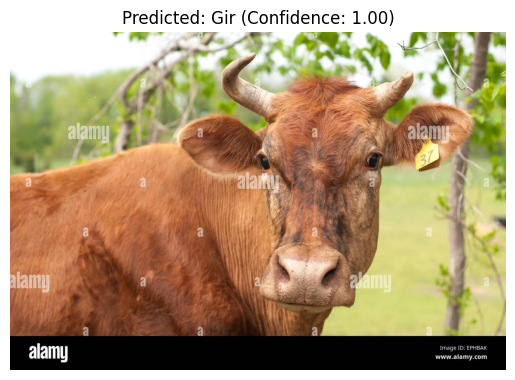

In [ ]:
import matplotlib.pyplot as plt

# Define the path to a new image file for testing.
# Choose an image file from the extracted dataset
data_dir = "/content/new_data" # Assuming the dataset is extracted here
new_image_path = os.path.join(data_dir, "brown.jpg") # Example path, modify as needed


# Call the preprocess_image function with the path of the new image
processed_new_image = preprocess_image(new_image_path)

# If the image preprocessing is successful, call the predict_breed function
if processed_new_image is not None:
    # Ensure class_names and loaded_model are available from previous successful steps
    if 'class_names' in globals() and class_names and 'loaded_model' in globals() and loaded_model is not None:
        predicted_breed, confidence = predict_breed(processed_new_image, loaded_model, class_names)

        # Print the predicted breed and confidence score.
        if predicted_breed:
            print(f"Prediction for {new_image_path}:")
            print(f"Predicted breed: {predicted_breed}")
            print(f"Confidence: {confidence:.2f}")

            # Visually inspect the new image
            img = Image.open(new_image_path)
            plt.imshow(img)
            plt.title(f"Predicted: {predicted_breed} (Confidence: {confidence:.2f})")
            plt.axis('off')
            plt.show()

        else:
            print("Could not make a prediction for the new image.")
    else:
        print("Error: Required variables (class_names or loaded_model) not found or invalid. Cannot make prediction.")
else:
    print(f"Image preprocessing failed for {new_image_path}.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')